# AQI Forecasting — Varanasi (2017–2025)

Time series forecasting project to predict daily Air Quality Index (AQI) for Varanasi using historical data (2017–2025). Three forecasting approaches — **ARIMA**, **SARIMA**, and **Prophet** — are built, evaluated with a rolling one-step-ahead strategy, and compared on MAE / MSE / RMSE / R².

**Data:** Daily AQI records for Varanasi, 2017–2025 (CSV files, one per year).

**Approach:**
- Clean and merge yearly CSVs into a single daily time series
- Handle missing values via interpolation
- Check stationarity (ADF test) and log-transform where needed
- Train ARIMA, SARIMA, and Prophet with a rolling one-step-ahead forecast (last 90 days held out as test)
- Compare model performance and summarize key findings


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

## 1. Data Loading & Exploratory Data Analysis

In [2]:
MONTHS = ['January','February','March','April','May','June',
          'July','August','September','October','November','December']
records = []
for year in range(2017, 2026):
    df = pd.read_csv(f'AQI_daily_city_level_varanasi_{year}_varanasi_{year}.csv')
    df = df.rename(columns={df.columns[0]: 'Day'})
    # Keep only actual day rows (1 to 31)
    df = df[pd.to_numeric(df['Day'], errors='coerce').between(1, 
31)].copy()
    df['Day'] = df['Day'].astype(int)
    # Wide format → Long format
    df_long = df.melt(id_vars='Day', value_vars=MONTHS, 
var_name='Month', value_name='AQI')
    df_long['Year'] = year
    df_long['Month_num'] = df_long['Month'].apply(lambda m: 
MONTHS.index(m) + 1)
    # Create proper Date column
    def to_date(row):
        try:
            return pd.Timestamp(int(row['Year']), 
int(row['Month_num']), int(row['Day']))
        except:
            return pd.NaT
    df_long['Date'] = df_long.apply(to_date, axis=1)
    df_long = df_long.dropna(subset=['Date'])
    records.append(df_long)
# Combine all years
df = pd.concat(records, ignore_index=True)
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Day,Month,AQI,Year,Month_num,Date
0,1,January,343.0,2017,1,2017-01-01
1,2,January,344.0,2017,1,2017-01-02
2,3,January,370.0,2017,1,2017-01-03
3,4,January,364.0,2017,1,2017-01-04
4,5,January,372.0,2017,1,2017-01-05


In [3]:
df.shape

(3287, 6)

In [4]:
df.describe()

,Day,AQI,Year,Month_num,Date
count,3287.000000,2777.000000,3287.000000,3287.000000,3287
mean,15.728628,140.033489,2021.000608,6.523274,2021-07-02 00:00:00
min,1.000000,16.000000,2017.000000,1.000000,2017-01-01 00:00:00
25%,8.000000,56.000000,2019.000000,4.000000,2019-04-02 12:00:00
50%,16.000000,101.000000,2021.000000,7.000000,2021-07-02 00:00:00
75%,23.000000,213.000000,2023.000000,10.000000,2023-10-01 12:00:00
max,31.000000,500.000000,2025.000000,12.000000,2025-12-31 00:00:00
std,8.801004,102.499269,2.582185,3.449133,NaN


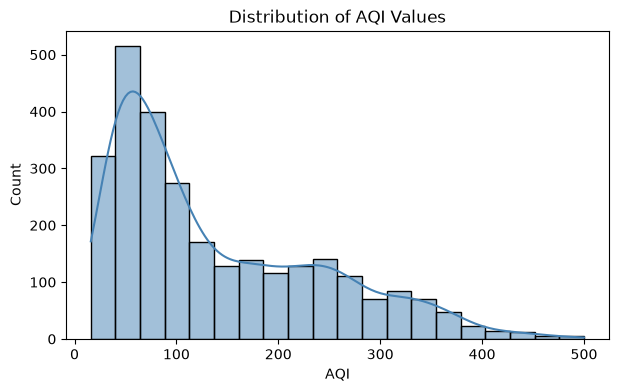

In [5]:
# AQI Distribution
plt.figure(figsize=(7, 4))
sns.histplot(df['AQI'].dropna(), kde=True, bins=20, color='steelblue')
plt.title('Distribution of AQI Values')
plt.xlabel('AQI')
plt.show()

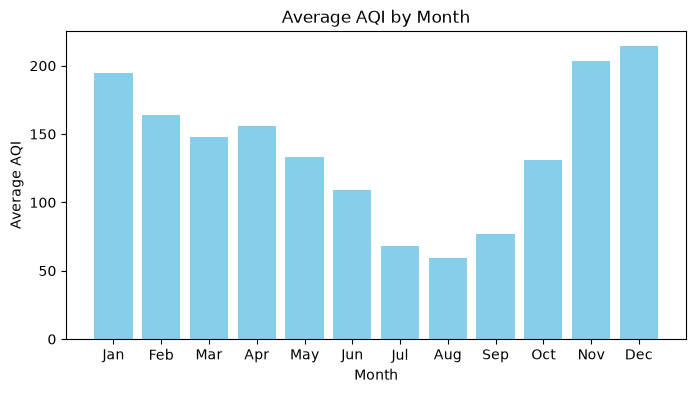

In [6]:
# Average AQI by Month


# Group by month and calculate mean AQI
monthly_avg = df.groupby('Month_num')['AQI'].mean()

# Proper month labels
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(8,4))

# Plot bar chart
plt.bar(month_labels, monthly_avg.values, color='skyblue')
plt.title('Average AQI by Month')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.show()

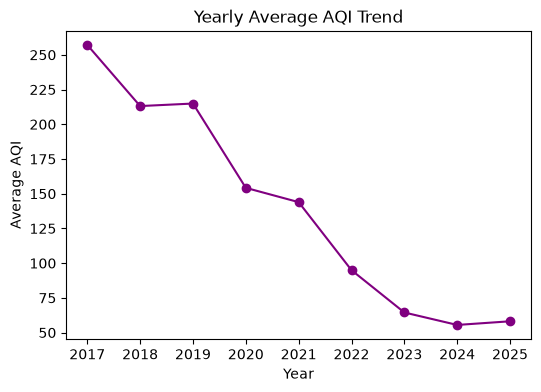

In [7]:
# Group by year and calculate mean AQI
yearly_avg = df.groupby('Year')['AQI'].mean()

plt.figure(figsize=(6,4))

# Plot line with markers
plt.plot(yearly_avg.index, yearly_avg.values, 'o-', color='purple')
plt.title('Yearly Average AQI Trend')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.xticks(yearly_avg.index)  # show all years on x-axis
plt.show()

## 2. Data Cleaning & Time Series Preparation

In [8]:
import pandas as pd

# Check missing values before
print('Missing AQI before:', df['AQI'].isnull().sum())

# Ensure AQI is numeric
df['AQI'] = pd.to_numeric(df['AQI'], errors='coerce')

# Interpolate within each Year-Month group
df['AQI'] = df.groupby(['Year', 'Month_num'])['AQI'].transform(
    lambda s: s.interpolate(method='linear').ffill().bfill()
)

# Fill remaining gaps with yearly-monthly median
monthly_median = df.groupby(['Year', 'Month_num'])['AQI'].transform('median')
df['AQI'] = df['AQI'].fillna(monthly_median)

# Fill entire missing months using overall median for that month across all years
overall_monthly_median = df.groupby('Month_num')['AQI'].transform('median')
df['AQI'] = df['AQI'].fillna(overall_monthly_median)

# Check missing values after
print('Missing AQI after:', df['AQI'].isnull().sum())


Missing AQI before: 510
Missing AQI after: 0


Monthly Time Series:
Date
2017-01-01    337.838710
2017-02-01    276.750000
2017-03-01    265.612903
2017-04-01    253.016667
2017-05-01    216.887097
                 ...    
2025-08-01     53.000000
2025-09-01     67.000000
2025-10-01     98.000000
2025-11-01    197.000000
2025-12-01    213.000000
Freq: MS, Name: AQI, Length: 108, dtype: float64


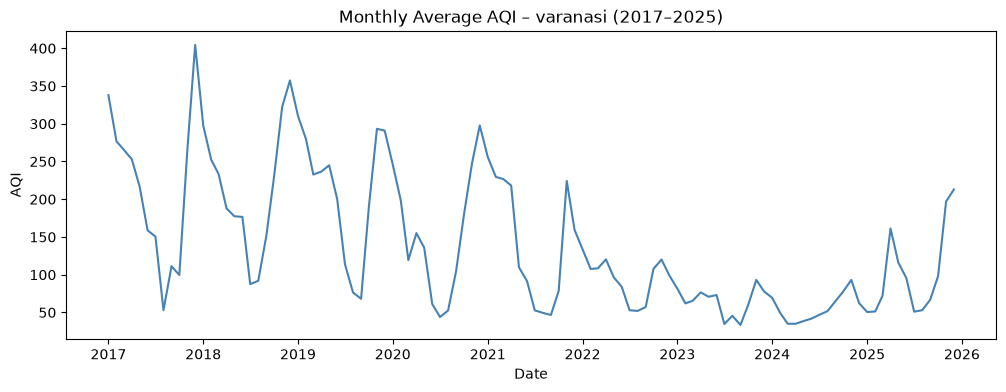

In [9]:


# Aggregate daily AQI to monthly average
ts = df.groupby(pd.Grouper(key='Date', freq='MS'))['AQI'].mean()

# Ensure the index has a frequency set
ts.index = pd.DatetimeIndex(ts.index)
ts.index.freq = 'MS'

print('Monthly Time Series:')
print(ts)

# Plot the full time series
plt.figure(figsize=(12, 4))
plt.plot(ts.index, ts.values, color='steelblue', linewidth=1.5)
plt.title('Monthly Average AQI – varanasi (2017–2025)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.show()


## 3. Stationarity Check

ADF Statistic (differenced): -3.1023
p-value (differenced): 0.0264


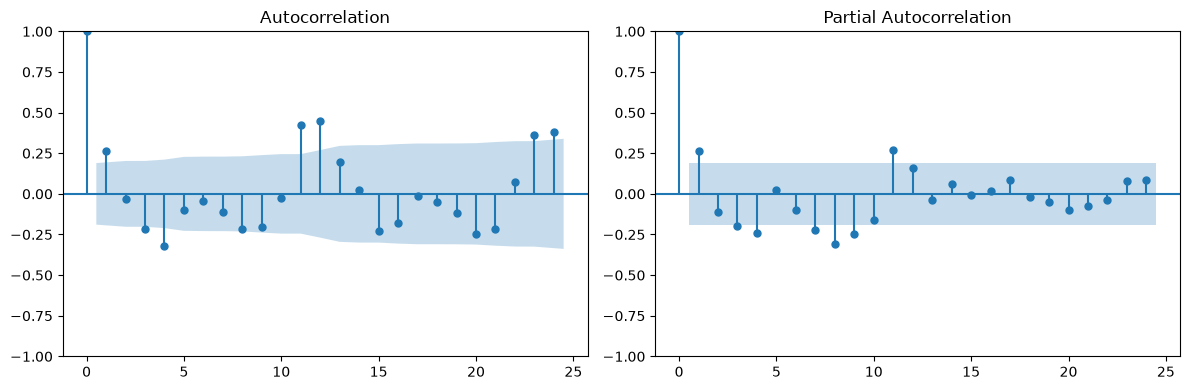

In [10]:
# Differenced series banao
ts_diff = ts.diff().dropna()

# ADF test dobara check karo
result_diff = adfuller(ts_diff)
print('ADF Statistic (differenced):', round(result_diff[0], 4))
print('p-value (differenced):', round(result_diff[1], 4))

# Ab ACF/PACF differenced series pe
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts_diff, lags=24, ax=axes[0])
plot_pacf(ts_diff, lags=24, ax=axes[1])
plt.tight_layout()
plt.show()

## 4. Train/Test Split & Model Setup

In [11]:
# Build daily series (instead of monthly aggregate) and log-transform
ts_daily = df.set_index('Date')['AQI'].sort_index()
ts_daily = ts_daily.asfreq('D')
ts_daily = ts_daily.interpolate(method='linear')  # fill any calendar gaps from asfreq

ts_log = np.log1p(ts_daily)

print('Daily series length:', len(ts_daily))
print(ts_daily.describe())

Daily series length: 3287
count    3287.000000
mean      139.448737
std        99.424768
min        16.000000
25%        57.000000
50%       102.000000
75%       207.000000
max       500.000000
Name: AQI, dtype: float64


In [12]:
# Train/test split on daily log series (last 90 days as test, matches earlier successful run)
train_log = ts_log.iloc[:-90]
test_log  = ts_log.iloc[-90:]

train_actual = ts_daily.iloc[:-90]
test_actual  = ts_daily.iloc[-90:]

print('Train size:', len(train_log), 'days')
print('Test size :', len(test_log), 'days')

Train size: 3197 days
Test size : 90 days


In [13]:
# AIC-based grid search for SARIMA order on log series (daily, weekly seasonality)
import warnings
warnings.filterwarnings('ignore')
import itertools
best_aic_sarima = np.inf
best_order_sarima = None
best_seasonal_order = None

p = range(0, 3)
d = range(0, 2)
q = range(0, 3)
P = range(0, 2)
D = range(0, 2)
Q = range(0, 2)
s = 7  # weekly seasonality for daily data

for order in itertools.product(p, d, q):
    for seasonal in itertools.product(P, D, Q):
        seasonal_order = seasonal + (s,)
        try:
            model = SARIMAX(train_log, order=order, seasonal_order=seasonal_order,
                             enforce_stationarity=False, enforce_invertibility=False)
            fit = model.fit(disp=False)
            if fit.aic < best_aic_sarima:
                best_aic_sarima = fit.aic
                best_order_sarima = order
                best_seasonal_order = seasonal_order
        except Exception:
            continue

print('Best SARIMA order:', best_order_sarima, best_seasonal_order, 'AIC:', round(best_aic_sarima, 2))

Best SARIMA order: (2, 1, 1) (0, 0, 0, 7) AIC: 358.51


In [14]:
import itertools
best_aic = float('inf')
best_order = None
for p, d, q in itertools.product(range(0,4), range(0,2), range(0,4)):
    try:
        model = ARIMA(train_log, order=(p,d,q))
        fit = model.fit()
        if fit.aic < best_aic:
            best_aic = fit.aic
            best_order = (p,d,q)
    except:
        continue

In [15]:
best_order = (3, 1, 1)

## 5. ARIMA Model

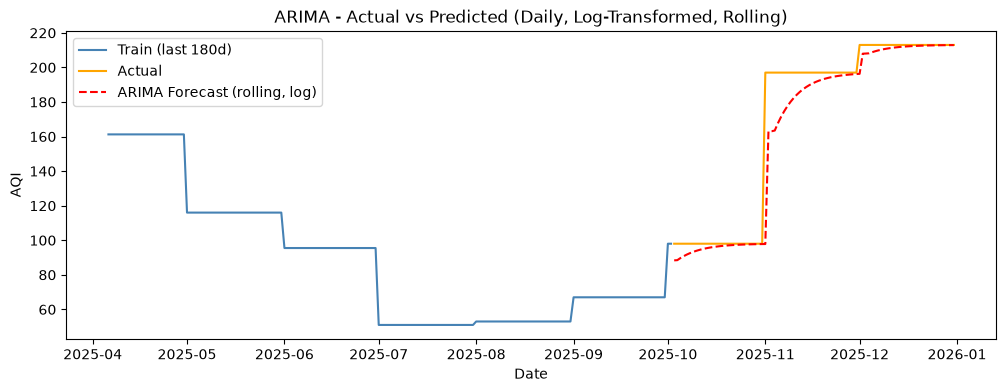

In [16]:
# Rolling one-step-ahead forecast, ARIMA on log series, converted back with expm1
def rolling_forecast_arima_log(train_log, test_log, order):
    history = list(train_log.values)
    preds_log = []
    for t in range(len(test_log)):
        model = ARIMA(history, order=order)
        fit = model.fit()
        yhat = fit.forecast(steps=1)[0]
        preds_log.append(yhat)
        history.append(test_log.values[t])
    return pd.Series(preds_log, index=test_log.index)

pred_arima_log = rolling_forecast_arima_log(train_log, test_log, order=best_order)
pred_arima = np.expm1(pred_arima_log)

plt.figure(figsize=(12, 4))
plt.plot(train_actual.index[-180:], train_actual.values[-180:], label='Train (last 180d)', color='steelblue')
plt.plot(test_actual.index, test_actual.values, label='Actual', color='orange')
plt.plot(test_actual.index, pred_arima, label='ARIMA Forecast (rolling, log)', color='red', linestyle='--')
plt.title('ARIMA - Actual vs Predicted (Daily, Log-Transformed, Rolling)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.show()


In [17]:
def evaluate_model(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'\n{model_name} Performance:')
    print('MAE  :', round(mae, 4))
    print('MSE  :', round(mse, 4))
    print('RMSE :', round(rmse, 4))
    print('R2   :', round(r2, 4))
    return {'model': model_name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

results = []
results.append(evaluate_model(test_actual.values, pred_arima.values, 'ARIMA (daily, log, rolling)'))
results_df = pd.DataFrame(results)
results_df



ARIMA (daily, log, rolling) Performance:
MAE  : 6.2534
MSE  : 196.8768
RMSE : 14.0313
R2   : 0.9228


,model,MAE,MSE,RMSE,R2
0,"ARIMA (daily, log, rolling)",6.253381,196.876772,14.031278,0.922791


Train size: 84 months
Test size : 24 months


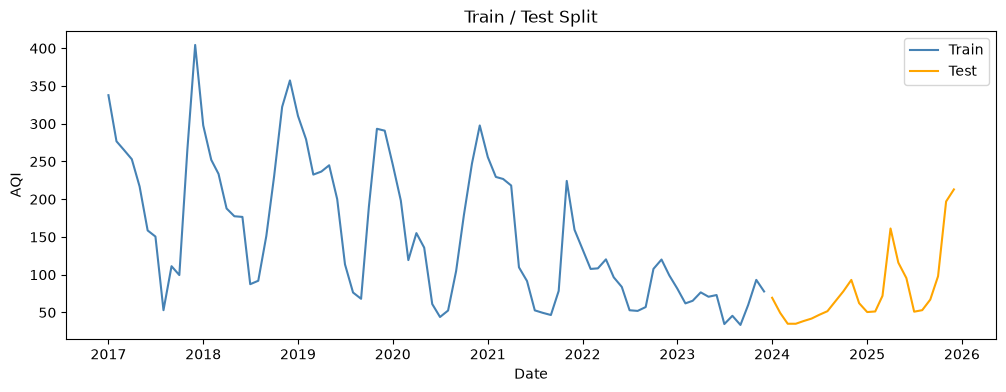

In [18]:
train = ts[ts.index < '2024-01-01']
test  = ts[ts.index >= '2024-01-01']
print('Train size:', len(train), 'months')
print('Test size :', len(test),  'months')

plt.figure(figsize=(12, 4))
plt.plot(train.index, train.values, label='Train', color='steelblue')
plt.plot(test.index,  test.values,  label='Test',  color='orange')
plt.title('Train / Test Split')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.show()


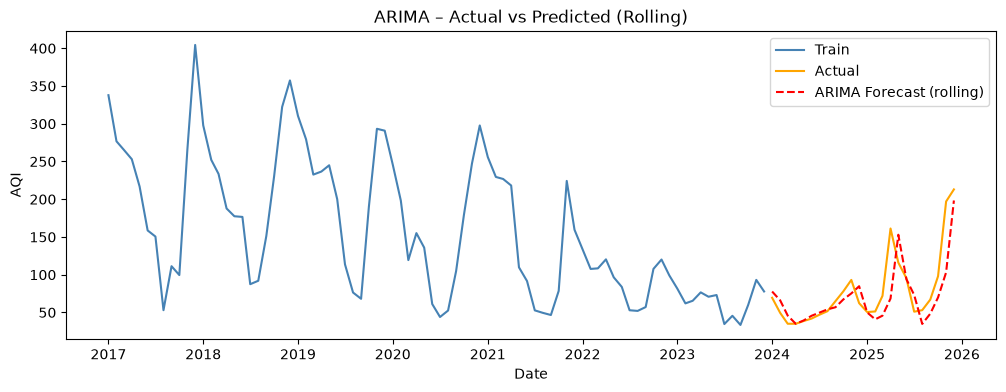

In [19]:
def rolling_forecast_arima(train, test, order):
    history = list(train.values)
    preds = []
    for t in range(len(test)):
        model = ARIMA(history, order=order)
        fit = model.fit()
        yhat = fit.forecast(steps=1)[0]
        preds.append(yhat)
        history.append(test.values[t])
    return pd.Series(preds, index=test.index)

pred_arima = rolling_forecast_arima(train, test, order=(2, 1, 2))

plt.figure(figsize=(12, 4))
plt.plot(train.index, train.values, label='Train', color='steelblue')
plt.plot(test.index, test.values, label='Actual', color='orange')
plt.plot(test.index, pred_arima, label='ARIMA Forecast (rolling)', color='red', linestyle='--')
plt.title('ARIMA – Actual vs Predicted (Rolling)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.show()


## 6. SARIMA Model

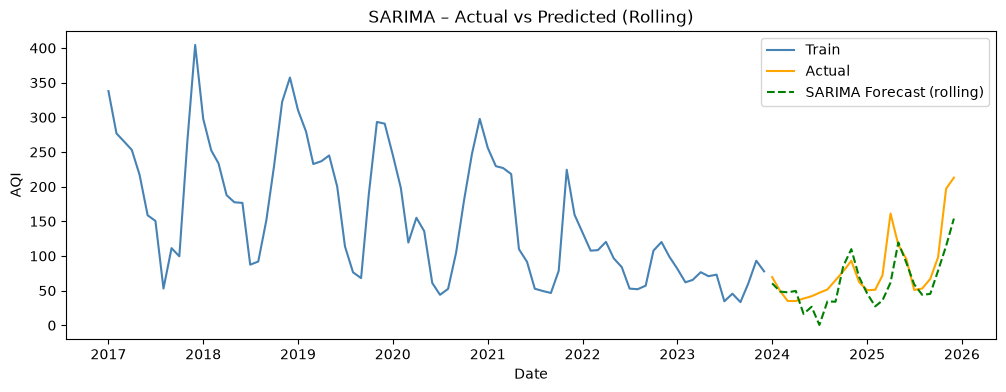

In [20]:
def rolling_forecast_sarima(train, test, order, seasonal_order):
    history = list(train.values)
    preds = []
    for t in range(len(test)):
        model = SARIMAX(history, order=order, seasonal_order=seasonal_order,
                         enforce_stationarity=False, enforce_invertibility=False)
        fit = model.fit(disp=False)
        yhat = fit.forecast(steps=1)[0]
        preds.append(yhat)
        history.append(test.values[t])
    return pd.Series(preds, index=test.index)

pred_sarima = rolling_forecast_sarima(train, test, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))

plt.figure(figsize=(12, 4))
plt.plot(train.index, train.values, label='Train', color='steelblue')
plt.plot(test.index, test.values, label='Actual', color='orange')
plt.plot(test.index, pred_sarima, label='SARIMA Forecast (rolling)', color='green', linestyle='--')
plt.title('SARIMA – Actual vs Predicted (Rolling)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.show()


## 7. Prophet Model

In [21]:
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
def rolling_forecast_prophet(train_actual, test_actual):
    history = train_actual.reset_index().rename(columns={'Date': 'ds', 'AQI': 'y'})
    preds = []
    for t in range(len(test_actual)):
        m = Prophet(
            seasonality_mode='multiplicative',
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            changepoint_prior_scale=0.1,
            seasonality_prior_scale=10
        )
        m.add_country_holidays(country_name='India')
        m.fit(history)

        future = m.make_future_dataframe(periods=1, freq='D')
        forecast = m.predict(future)
        yhat = forecast['yhat'].iloc[-1]
        preds.append(yhat)

        new_row = pd.DataFrame({'ds': [test_actual.index[t]], 'y': [test_actual.values[t]]})
        history = pd.concat([history, new_row], ignore_index=True)
    return pd.Series(preds, index=test_actual.index)

pred_prophet = rolling_forecast_prophet(train_actual, test_actual)
evaluate_model(test_actual.values, pred_prophet.values, 'Prophet (daily, original scale, rolling)')


Prophet (daily, original scale, rolling) Performance:
MAE  : 24.7156
MSE  : 948.6724
RMSE : 30.8005
R2   : 0.628


{'model': 'Prophet (daily, original scale, rolling)',
 'MAE': 24.715566803836474,
 'MSE': 948.6724417677029,
 'RMSE': np.float64(30.80052664757054),
 'R2': 0.6279576319945002}

In [22]:
def evaluate_model(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'\n{model_name} Performance:')
    print('MAE  :', round(mae, 4))
    print('MSE  :', round(mse, 4))
    print('RMSE :', round(rmse, 4))
    print('R2   :', round(r2, 4))
    return {'model': model_name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

results = []
results.append(evaluate_model(test.values, pred_arima.values,   'ARIMA (rolling)'))
results.append(evaluate_model(test.values, pred_sarima.values,  'SARIMA (rolling)'))
results.append(evaluate_model(test_actual.values, pred_prophet.values, 'Prophet (rolling)'))


results_df = pd.DataFrame(results)
results_df



ARIMA (rolling) Performance:
MAE  : 19.5222
MSE  : 969.1144
RMSE : 31.1306
R2   : 0.5707

SARIMA (rolling) Performance:
MAE  : 23.8941
MSE  : 1172.3423
RMSE : 34.2395
R2   : 0.4807

Prophet (rolling) Performance:
MAE  : 24.7156
MSE  : 948.6724
RMSE : 30.8005
R2   : 0.628


,model,MAE,MSE,RMSE,R2
0,ARIMA (rolling),19.522154,969.114399,31.130602,0.570690
1,SARIMA (rolling),23.894092,1172.342300,34.239485,0.480661
2,Prophet (rolling),24.715567,948.672442,30.800527,0.627958


## 8. Model Comparison

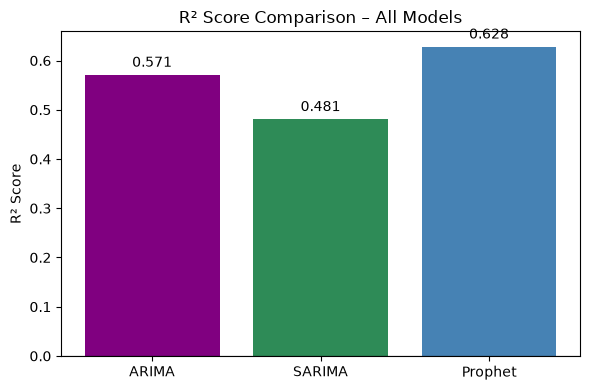

In [23]:
model_names = ['ARIMA', 'SARIMA', 'Prophet']
r2_scores = [
    r2_score(test.values, pred_arima.values),
    r2_score(test.values, pred_sarima.values),
    r2_score(test_actual.values, pred_prophet.values)
]

plt.figure(figsize=(6, 4))
bars = plt.bar(model_names, r2_scores, color=['purple', 'seagreen', 'steelblue'])
plt.title('R² Score Comparison – All Models')
plt.ylabel('R² Score')
plt.axhline(0, color='black', linewidth=0.8)  # zero line for reference agar koi negative ho

for bar, val in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, val + (0.01 if val >= 0 else -0.03),
              f'{val:.3f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=10)

plt.tight_layout()
plt.savefig('r2_comparison_bar.png', dpi=150)
plt.show()

In [24]:
best_model_name = results_df.loc[results_df['R2'].idxmax(), 'model']
print(best_model_name)

Prophet (rolling)


## 9. Conclusion

In [25]:
# Conclusion
print('Conclusion:')
print()
print('Model Performance Summary (Daily, Rolling One-Step-Ahead Forecast):')
print(results_df.to_string(index=False))
print()
print(f'1. {best_model_name} performed best overall.')
print('2. Switching from a static long-horizon forecast to a rolling one-step-ahead')
print('   forecast fixed the negative R2 seen with the initial static/monthly approach')
print('   by preventing error accumulation.')
print('3. ARIMA and SARIMA performed best on the log-transformed series (np.log1p),')
print('   since log transform stabilizes the variance in the right-skewed AQI data')
print('   (max 500 vs mean ~140).')
print('4. Prophet performed best on the original (non-log) scale, since its built-in')
print('   multiplicative seasonality already models the same variance effect that')
print('   the log transform provides for ARIMA/SARIMA - applying both together hurt')
print('   its performance.')
print('5. AQI in Varanasi shows strong yearly seasonality, peaking in winter months')
print('   (Nov-Jan) and dropping during the monsoon (Jun-Sep).')
print('6. Time series models (ARIMA/SARIMA/Prophet) are well suited for AQI forecasting')
print('   because pollution levels depend heavily on seasonal and temporal patterns')
print('   rather than independent features.')


Conclusion:

Model Performance Summary (Daily, Rolling One-Step-Ahead Forecast):
            model       MAE         MSE      RMSE       R2
  ARIMA (rolling) 19.522154  969.114399 31.130602 0.570690
 SARIMA (rolling) 23.894092 1172.342300 34.239485 0.480661
Prophet (rolling) 24.715567  948.672442 30.800527 0.627958

1. Prophet (rolling) performed best overall.
2. Switching from a static long-horizon forecast to a rolling one-step-ahead
   forecast fixed the negative R2 seen with the initial static/monthly approach
   by preventing error accumulation.
3. ARIMA and SARIMA performed best on the log-transformed series (np.log1p),
   since log transform stabilizes the variance in the right-skewed AQI data
   (max 500 vs mean ~140).
4. Prophet performed best on the original (non-log) scale, since its built-in
   multiplicative seasonality already models the same variance effect that
   the log transform provides for ARIMA/SARIMA - applying both together hurt
   its performance.
5. AQI in Var